<a href="https://colab.research.google.com/github/agraish/ML_Kaltsum-A.-Mahbubah/blob/main/Kaltsum_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
# IMPORT LIBRARY
# library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [131]:
# LOAD DATA
df = pd.read_csv("Diamond Price Prediction.csv")
df.head()

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [132]:
# DATA UNDERSTANDING
df.columns = df.columns.str.strip()
list(df.columns)

['Carat(Weight of Daimond)',
 'Cut(Quality)',
 'Color',
 'Clarity',
 'Depth',
 'Table',
 'Price(in US dollars)',
 'X(length)',
 'Y(width)',
 'Z(Depth)']

In [133]:
# shape data
df.shape

(53940, 10)

In [134]:
# info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Carat(Weight of Daimond)  53940 non-null  float64
 1   Cut(Quality)              53940 non-null  object 
 2   Color                     53940 non-null  object 
 3   Clarity                   53940 non-null  object 
 4   Depth                     53940 non-null  float64
 5   Table                     53940 non-null  float64
 6   Price(in US dollars)      53940 non-null  int64  
 7   X(length)                 53940 non-null  float64
 8   Y(width)                  53940 non-null  float64
 9   Z(Depth)                  53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [135]:
# missing value
df.isnull().sum()

,0
Carat(Weight of Daimond),0
Cut(Quality),0
Color,0
Clarity,0
Depth,0
Table,0
Price(in US dollars),0
X(length),0
Y(width),0
Z(Depth),0


In [136]:
# statistik deskriptif
df.describe(include='all')

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [137]:
# DATA PREPROCESSING
# cari target otomatis
target_candidates = [col for col in df.columns if 'price' in col.lower()]
target_col = target_candidates[0]
target_col

'Price(in US dollars)'

In [138]:
# drop kolom tidak penting
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [139]:
# cek duplikat
df.duplicated().sum()

np.int64(146)

In [140]:
df.duplicated().sum()


np.int64(146)

In [141]:
# handle missing value
df = df.dropna()
df.isnull().sum()

,0
Carat(Weight of Daimond),0
Cut(Quality),0
Color,0
Clarity,0
Depth,0
Table,0
Price(in US dollars),0
X(length),0
Y(width),0
Z(Depth),0


In [142]:
# cek kolom kategorikal
df.select_dtypes(include='object').columns

Index(['Cut(Quality)', 'Color', 'Clarity'], dtype='object')

In [143]:
# ubah kategorikal ke numerik
df_model = pd.get_dummies(df, drop_first=True, dtype=int)
df_model.head()

,Carat(Weight of Daimond),Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,0,...,0,0,1,0,0,1,0,0,0,0


In [144]:
# simpan data untuk eda
df_eda = df_model.copy()
df_eda.shape

(53940, 24)

In [145]:
# cek semua tipe data
df_model.dtypes

,0
Carat(Weight of Daimond),float64
Depth,float64
Table,float64
Price(in US dollars),int64
X(length),float64
Y(width),float64
Z(Depth),float64
Cut(Quality)_Good,int64
Cut(Quality)_Ideal,int64
Cut(Quality)_Premium,int64


In [146]:
# handle outlier
kolom_numerik = df_model.select_dtypes(include=np.number).columns

Q1 = df_model[kolom_numerik].quantile(0.25)
Q3 = df_model[kolom_numerik].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_model[kolom_numerik] < (Q1 - 1.5 * IQR)) |
         (df_model[kolom_numerik] > (Q3 + 1.5 * IQR))).any(axis=1)

df_model = df_model[mask]
df_model.shape

(26, 24)

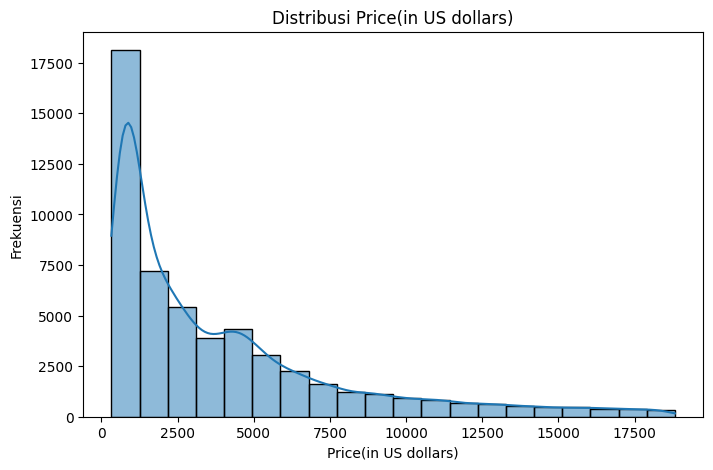

In [147]:
# EDA
# distribusi target
plt.figure(figsize=(8,5))
sns.histplot(df_eda[target_col], bins=20, kde=True)
plt.title(f'Distribusi {target_col}')
plt.xlabel(target_col)
plt.ylabel('Frekuensi')
plt.show()

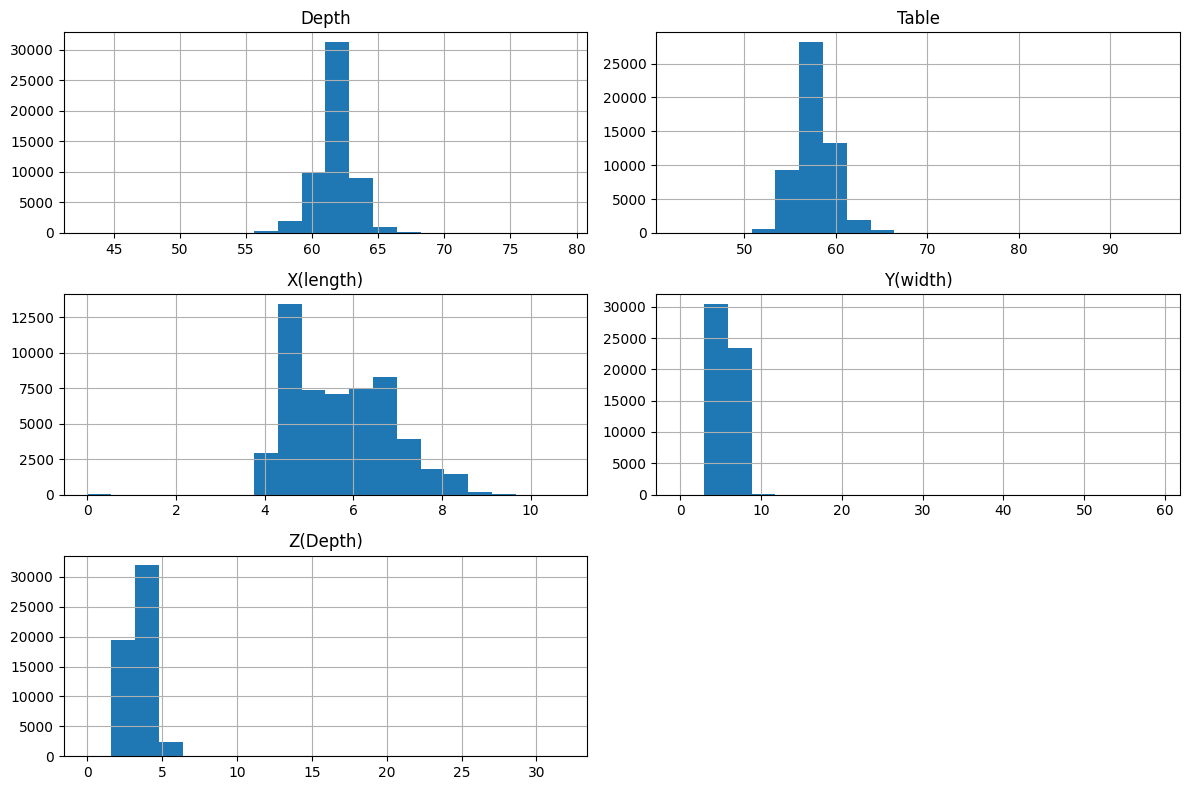

In [148]:
# distribusi fitur numerik utama
fitur_hist_baru = [col for col in [
    'Carat(Weight of Diamond)',
    'Depth',
    'Table',
    'X(length)',
    'Y(width)',
    'Z(Depth)'
] if col in df_eda.columns]

df_eda[fitur_hist_baru].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

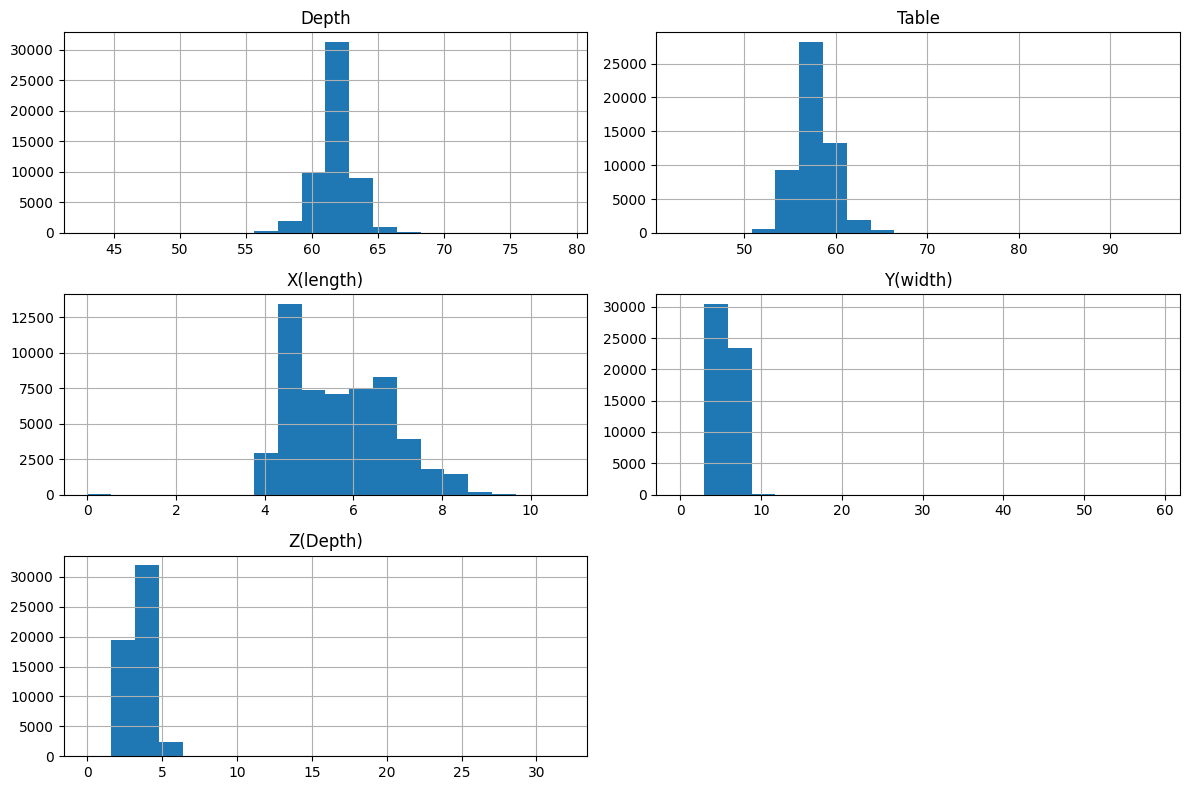

In [149]:
# distribusi fitur numerik utama
fitur_hist_baru = [col for col in [
    'Carat(Weight of Diamond)',
    'Depth',
    'Table',
    'X(length)',
    'Y(width)',
    'Z(Depth)'
] if col in df_eda.columns]

df_eda[fitur_hist_baru].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

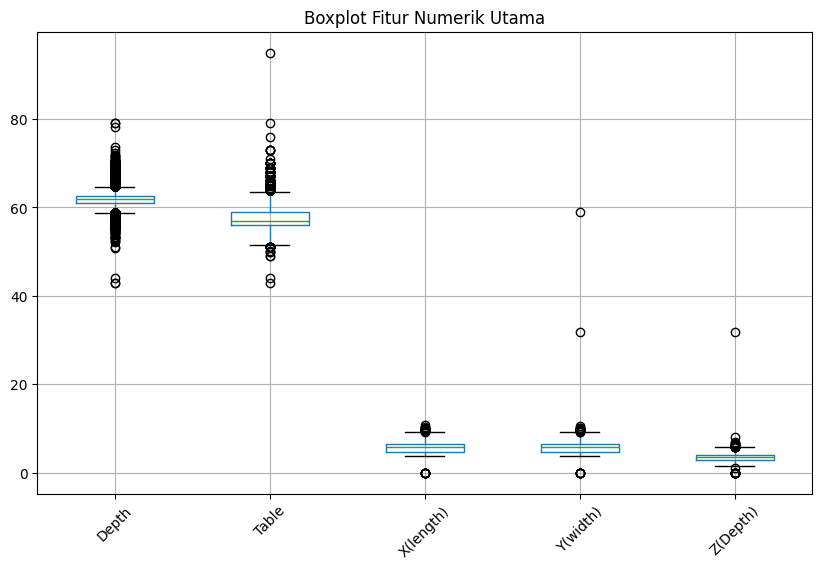

In [150]:
# boxplot fitur numerik utama
fitur_boxplot_baru = [col for col in [
    'Carat(Weight of Diamond)',
    'Depth',
    'Table',
    'X(length)',
    'Y(width)',
    'Z(Depth)'
] if col in df_eda.columns]

plt.figure(figsize=(10,6))
df_eda[fitur_boxplot_baru].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot Fitur Numerik Utama')
plt.show()

In [151]:
'Carat(Weight of Diamond)' in df_eda.columns

False

In [152]:
# tabel korelasi target
corr_target = df_eda.corr(numeric_only=True)[[target_col]].sort_values(by=target_col, ascending=False)
corr_target.head(10)

,Price(in US dollars)
Price(in US dollars),1.000000
Carat(Weight of Daimond),0.921591
X(length),0.884435
Y(width),0.865421
Z(Depth),0.861249
Clarity_SI2,0.128420
Table,0.127134
Color_I,0.097125
Cut(Quality)_Premium,0.095706
Color_J,0.081710


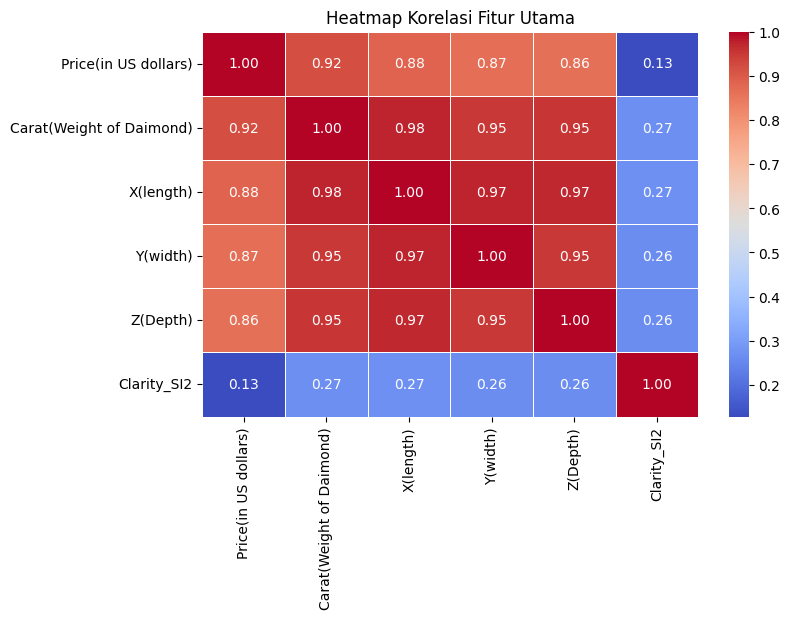

In [153]:
# heatmap korelasi
fitur_heatmap = corr_target.index[:6].tolist()

plt.figure(figsize=(8,5))
sns.heatmap(df_eda[fitur_heatmap].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Utama')
plt.show()

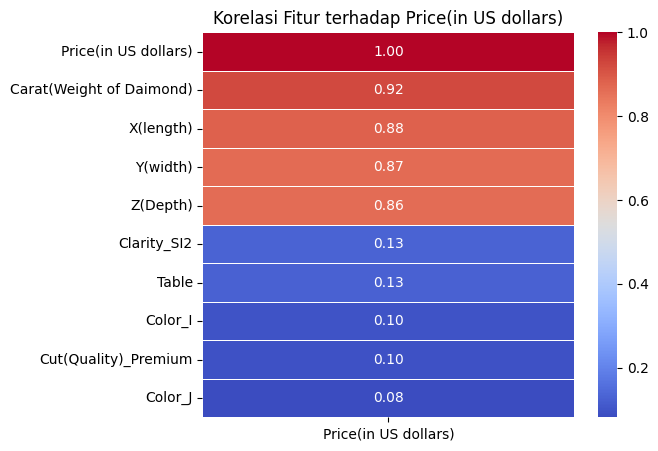

In [154]:
# heatmap korelasi target
plt.figure(figsize=(6,5))
sns.heatmap(corr_target.head(10), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'Korelasi Fitur terhadap {target_col}')
plt.show()

In [155]:
# DATA SPLITTING
# fitur dan target
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

X.head()

,Carat(Weight of Daimond),Depth,Table,X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,Cut(Quality)_Very Good,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
844,1.08,61.9,60.0,6.55,6.48,4.03,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4295,1.11,61.9,58.0,6.63,6.66,4.11,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4556,1.16,61.8,59.0,6.74,6.78,4.18,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4591,1.11,61.9,58.0,6.66,6.63,4.11,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4859,1.16,61.8,59.0,6.78,6.74,4.18,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [156]:
# split 70 30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [157]:
# split 80 20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [158]:
# split 90 10
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [159]:
# NORMALISASI
# normalisasi 70 30
scaler_70 = StandardScaler()
X_train_70_scaled = scaler_70.fit_transform(X_train_70)
X_test_70_scaled = scaler_70.transform(X_test_70)

In [160]:
# normalisasi 80 20
scaler_80 = StandardScaler()
X_train_80_scaled = scaler_80.fit_transform(X_train_80)
X_test_80_scaled = scaler_80.transform(X_test_80)

In [161]:
# normalisasi 90 10
scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_90_scaled = scaler_90.transform(X_test_90)

In [162]:
# normalisasi 90 10
scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_90_scaled = scaler_90.transform(X_test_90)

In [163]:
# EVALUASI FUNCTION
# fungsi evaluasi regresi
def evaluasi_regresi(y_true, y_pred):
    return pd.DataFrame({
        'MAE': [mean_absolute_error(y_true, y_pred)],
        'MSE': [mean_squared_error(y_true, y_pred)],
        'RMSE': [np.sqrt(mean_squared_error(y_true, y_pred))],
        'R2': [r2_score(y_true, y_pred)]
    })

In [164]:
# MODEL XGBOOST
# training model awal
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_80_scaled, y_train_80)

y_pred_xgb = xgb_model.predict(X_test_80_scaled)

In [165]:
# evaluasi model awal
hasil_xgb_awal = evaluasi_regresi(y_test_80, y_pred_xgb)
hasil_xgb_awal

,MAE,MSE,RMSE,R2
0,188.095383,112872.132812,335.964481,0.946638


In [166]:
# HYPERPARAMETER XGBOOST
# tuning xgboost
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_xgb.best_params_])

,learning_rate,max_depth,n_estimators
0,0.1,3,100


In [167]:
# evaluasi setelah tuning
best_xgb = grid_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_80_scaled)

hasil_xgb_tuned = evaluasi_regresi(y_test_80, y_pred_xgb_tuned)
hasil_xgb_tuned

,MAE,MSE,RMSE,R2
0,251.173019,141015.4375,375.520222,0.933333


In [168]:
# MODEL LIGHTGBM
# training model awal
lgbm_model = LGBMRegressor(random_state=42)
lgbm_model.fit(X_train_80_scaled, y_train_80)

y_pred_lgbm = lgbm_model.predict(X_test_80_scaled)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 20, number of used features: 0
[LightGBM] [Info] Start training from score 3453.200000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [169]:
# evaluasi model awal
hasil_lgbm_awal = evaluasi_regresi(y_test_80, y_pred_lgbm)
hasil_lgbm_awal

,MAE,MSE,RMSE,R2
0,1137.933333,2116196.44,1454.715244,-0.00046


In [170]:
# HYPERPARAMETER LIGHTGBM
# tuning lightgbm
param_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_lgbm = GridSearchCV(
    estimator=LGBMRegressor(random_state=42),
    param_grid=param_lgbm,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_lgbm.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_lgbm.best_params_])

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 20, number of used features: 0
[LightGBM] [Info] Start training from score 3453.200000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the s

,learning_rate,max_depth,n_estimators
0,0.05,3,100


In [171]:
# evaluasi setelah tuning
best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test_80_scaled)

hasil_lgbm_tuned = evaluasi_regresi(y_test_80, y_pred_lgbm_tuned)
hasil_lgbm_tuned

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,MSE,RMSE,R2
0,1137.933333,2116196.44,1454.715244,-0.00046


In [172]:
# MODEL HISTGRADIENTBOOSTING
# training model awal
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train_80_scaled, y_train_80)

y_pred_hgb = hgb_model.predict(X_test_80_scaled)

In [173]:
# evaluasi model awal
hasil_hgb_awal = evaluasi_regresi(y_test_80, y_pred_hgb)
hasil_hgb_awal

,MAE,MSE,RMSE,R2
0,1137.933333,2116196.44,1454.715244,-0.00046


In [174]:
# HYPERPARAMETER HISTGRADIENTBOOSTING
# tuning histgradientboosting
param_hgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'max_iter': [100, 200]
}

grid_hgb = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_grid=param_hgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_hgb.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_hgb.best_params_])

,learning_rate,max_depth,max_iter
0,0.05,3,100


In [175]:
# evaluasi setelah tuning
best_hgb = grid_hgb.best_estimator_
y_pred_hgb_tuned = best_hgb.predict(X_test_80_scaled)

hasil_hgb_tuned = evaluasi_regresi(y_test_80, y_pred_hgb_tuned)
hasil_hgb_tuned

,MAE,MSE,RMSE,R2
0,1137.933333,2116196.44,1454.715244,-0.00046


In [176]:
# MODEL EVALUATION
# ringkasan xgboost
ringkasan_xgb = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_xgb_awal['MAE'][0], hasil_xgb_tuned['MAE'][0]],
    'MSE': [hasil_xgb_awal['MSE'][0], hasil_xgb_tuned['MSE'][0]],
    'RMSE': [hasil_xgb_awal['RMSE'][0], hasil_xgb_tuned['RMSE'][0]],
    'R2': [hasil_xgb_awal['R2'][0], hasil_xgb_tuned['R2'][0]]
})

ringkasan_xgb

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,188.095383,112872.132812,335.964481,0.946638
1,Setelah Tuning,251.173019,141015.437500,375.520222,0.933333


In [177]:
# MODEL EVALUATION
# ringkasan lightgbm
ringkasan_lgbm = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_lgbm_awal['MAE'][0], hasil_lgbm_tuned['MAE'][0]],
    'MSE': [hasil_lgbm_awal['MSE'][0], hasil_lgbm_tuned['MSE'][0]],
    'RMSE': [hasil_lgbm_awal['RMSE'][0], hasil_lgbm_tuned['RMSE'][0]],
    'R2': [hasil_lgbm_awal['R2'][0], hasil_lgbm_tuned['R2'][0]]
})

ringkasan_lgbm

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,1137.933333,2116196.44,1454.715244,-0.00046
1,Setelah Tuning,1137.933333,2116196.44,1454.715244,-0.00046


In [178]:
# MODEL EVALUATION
# ringkasan histgradientboosting
ringkasan_hgb = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_hgb_awal['MAE'][0], hasil_hgb_tuned['MAE'][0]],
    'MSE': [hasil_hgb_awal['MSE'][0], hasil_hgb_tuned['MSE'][0]],
    'RMSE': [hasil_hgb_awal['RMSE'][0], hasil_hgb_tuned['RMSE'][0]],
    'R2': [hasil_hgb_awal['R2'][0], hasil_hgb_tuned['R2'][0]]
})

ringkasan_hgb

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,1137.933333,2116196.44,1454.715244,-0.00046
1,Setelah Tuning,1137.933333,2116196.44,1454.715244,-0.00046


In [179]:
# MODEL COMPARISON
# perbandingan semua model
evaluation_model = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'HistGradientBoosting'],
    'MAE Awal': [
        hasil_xgb_awal['MAE'][0],
        hasil_lgbm_awal['MAE'][0],
        hasil_hgb_awal['MAE'][0]
    ],
    'MSE Awal': [
        hasil_xgb_awal['MSE'][0],
        hasil_lgbm_awal['MSE'][0],
        hasil_hgb_awal['MSE'][0]
    ],
    'RMSE Awal': [
        hasil_xgb_awal['RMSE'][0],
        hasil_lgbm_awal['RMSE'][0],
        hasil_hgb_awal['RMSE'][0]
    ],
    'R2 Awal': [
        hasil_xgb_awal['R2'][0],
        hasil_lgbm_awal['R2'][0],
        hasil_hgb_awal['R2'][0]
    ],
    'MAE Setelah Tuning': [
        hasil_xgb_tuned['MAE'][0],
        hasil_lgbm_tuned['MAE'][0],
        hasil_hgb_tuned['MAE'][0]
    ],
    'MSE Setelah Tuning': [
        hasil_xgb_tuned['MSE'][0],
        hasil_lgbm_tuned['MSE'][0],
        hasil_hgb_tuned['MSE'][0]
    ],
    'RMSE Setelah Tuning': [
        hasil_xgb_tuned['RMSE'][0],
        hasil_lgbm_tuned['RMSE'][0],
        hasil_hgb_tuned['RMSE'][0]
    ],
    'R2 Setelah Tuning': [
        hasil_xgb_tuned['R2'][0],
        hasil_lgbm_tuned['R2'][0],
        hasil_hgb_tuned['R2'][0]
    ]
})

evaluation_model

,Model,MAE Awal,MSE Awal,RMSE Awal,R2 Awal,MAE Setelah Tuning,MSE Setelah Tuning,RMSE Setelah Tuning,R2 Setelah Tuning
0,XGBoost,188.095383,1.128721e+05,335.964481,0.946638,251.173019,1.410154e+05,375.520222,0.933333
1,LightGBM,1137.933333,2.116196e+06,1454.715244,-0.000460,1137.933333,2.116196e+06,1454.715244,-0.000460
2,HistGradientBoosting,1137.933333,2.116196e+06,1454.715244,-0.000460,1137.933333,2.116196e+06,1454.715244,-0.000460


In [180]:
# INFERENCE
# data sample
sample_data = X.iloc[[0]]
sample_data

,Carat(Weight of Daimond),Depth,Table,X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,Cut(Quality)_Very Good,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
844,1.08,61.9,60.0,6.55,6.48,4.03,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [181]:
# hasil prediksi
sample_scaled = scaler_80.transform(sample_data)
prediksi = best_xgb.predict(sample_scaled)

pd.DataFrame({
    f'Prediksi {target_col}': prediksi
})

,Prediksi Price(in US dollars)
0,3735.905029


In [182]:
# SAVE MODEL
# simpan model
joblib.dump(best_xgb, 'best_xgb_model.pkl')
joblib.dump(scaler_80, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [183]:
# DEPLOYMENT
# buat app streamlit
app_code = f"""
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('best_xgb_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')

st.title('Prediksi Harga Berlian')
st.write('Aplikasi sederhana untuk memprediksi {target_col}')

input_data = pd.DataFrame(0, index=[0], columns=feature_columns)

for col in feature_columns:
    if col.startswith('cut_') or col.startswith('color_') or col.startswith('clarity_'):
        continue
    input_data.loc[0, col] = st.number_input(col, value=1.0)

if st.button('Prediksi'):
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    st.success(f'Prediksi {target_col}: {{prediction[0]:.2f}}')
"""

with open('app.py', 'w') as f:
    f.write(app_code)

pd.DataFrame({'file': ['app.py'], 'status': ['berhasil dibuat']})

,file,status
0,app.py,berhasil dibuat


In [184]:
# DEPLOYMENT
# install streamlit
!pip install streamlit

In [185]:
# cek streamlit
!python -m streamlit --version

Streamlit, version 1.56.0


In [ ]:
# run streamlit
!python -m streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.6.174.196:8501

